# A04: Model Interpretability (xAI)
-----------------------------------
**Your Name Here:Yeongeun Ra **

You previously worked with this dataset on the 'Sampling' notebooks. Now, you will try to interpret the model!

You will build a classification model of your choice (you may use SMOTE or not - I'm not testing how good your model is for this assignment, just that you know how to interpret the model!). You must do some form of autoML or grid search...

The target variable is Loan_Status (thanks Ahmend for the heads-up!)

Then you will:
* Print the Top 5 features (using permutation importance with 20 repeats) in a box plot.
* Create the partial dependence plots for the top 5 features (you may opt to use the num_grid_points argument). Customize the plots so that the Y axis is consistent on each of the five plots.
* Write five meaningful bullets about what you see in the plots. Does anything surprise you? What do the X and Y axis mean in each plot?
  * Optional: Any issues with correlated predictors (read here for a cool way on how to address this: https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance_multicollinear.html)?

In [ ]:
#https://drive.google.com/file/d/1CppeqGbiBzX61jx56gcXyGGDNEeLlJ-W/view?usp=share_link
#!gdown 1CppeqGbiBzX61jx56gcXyGGDNEeLlJ-W

Downloading...
From: https://drive.google.com/uc?id=1CppeqGbiBzX61jx56gcXyGGDNEeLlJ-W
To: /content/train_loan_imbalanced.csv
100% 38.0k/38.0k [00:00<00:00, 34.8MB/s]


In [2]:
import pandas as pd
#df = pd.read_csv('/content/train_loan_imbalanced.csv')
df = pd.read_csv('./data/train_loan_imbalanced.csv')

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
# good luck!

# 1. Load Package

In [4]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# preprocessing / modeling
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

# model evaluation
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

# classification model
from sklearn.ensemble import RandomForestClassifier

# xAI / interpretation
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay

# 2. Load and inspect the data

In [5]:
# quick check
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [6]:
# shape of the data
df.shape

(614, 13)

In [7]:
# data types
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [8]:
# check missing values
df.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

# 3. Data cleaning and preprocessing 

In [9]:
# Drop Loan_ID because it is only an identifier

if 'Loan_ID' in df.columns:
    df = df.drop(columns=['Loan_ID'])

In [10]:
# Drop missing values

df = df.dropna()

In [11]:
# Convert target variable

df['Loan_Status'] = df['Loan_Status'].map({
    'N':0,
    'Y':1
})

In [12]:
# Create X and Y

X = df.drop('Loan_Status', axis=1)
Y = df['Loan_Status']

In [13]:
# Convert categorical variables to dummy variables

X = pd.get_dummies(
    X,
    drop_first=True
)

In [14]:
# quick check

X.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
1,4583,1508.0,128.0,360.0,1.0,True,True,True,False,False,False,False,False,False
2,3000,0.0,66.0,360.0,1.0,True,True,False,False,False,False,True,False,True
3,2583,2358.0,120.0,360.0,1.0,True,True,False,False,False,True,False,False,True
4,6000,0.0,141.0,360.0,1.0,True,False,False,False,False,False,False,False,True
5,5417,4196.0,267.0,360.0,1.0,True,True,False,True,False,False,True,False,True


# 4. Train/test split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    shuffle=True,
    random_state=42,
    stratify=Y
)

# 5. Grid Search Classification Model

In [16]:
# 1. Construct the model 
rf = RandomForestClassifier(
    random_state=42
)

In [17]:
# 2. parameter grid 
param_grid = {
    'n_estimators':[100, 200],
    'max_depth':[3, 5, None],
    'min_samples_split':[2, 5]
}

In [18]:
# 3. grid search 
gs_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)
# fit the grid search

gs_rf.fit(
    X_train,
    y_train
)


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, None], 'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

In [19]:
# 4. best model 
# best parameters

gs_rf.best_params_

{'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 200}

In [20]:
# best cross validation score

gs_rf.best_score_

0.8020164046479836

In [21]:
# save best model

clf = gs_rf.best_estimator_

# 6. Model evaluation 

In [22]:
# predictions

y_pred = clf.predict(X_test)

In [23]:
# accuracy

accuracy_score(
    y_test,
    y_pred
)

0.8125

In [24]:
# confusion matrix

confusion_matrix(
    y_test,
    y_pred
)

array([[15, 15],
       [ 3, 63]])

In [25]:
# classification report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.50      0.62        30
           1       0.81      0.95      0.88        66

    accuracy                           0.81        96
   macro avg       0.82      0.73      0.75        96
weighted avg       0.82      0.81      0.80        96



# 7. Permutation importance

In [26]:
# 1. calculate permutation importance
result = permutation_importance(
    clf,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring='accuracy'
)

In [29]:
#2. sort features 
perm_sorted_idx = result.importances_mean.argsort()
top5_idx = perm_sorted_idx[-5:]
top5_features = X.columns[top5_idx]
top5_features

Index(['Property_Area_Urban', 'Self_Employed_Yes', 'Dependents_2',
       'Dependents_3+', 'Credit_History'],
      dtype='object')

/var/folders/tg/ntvm9wc94h937xqtzftck9xc0000gn/T/ipykernel_6121/3158456511.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(


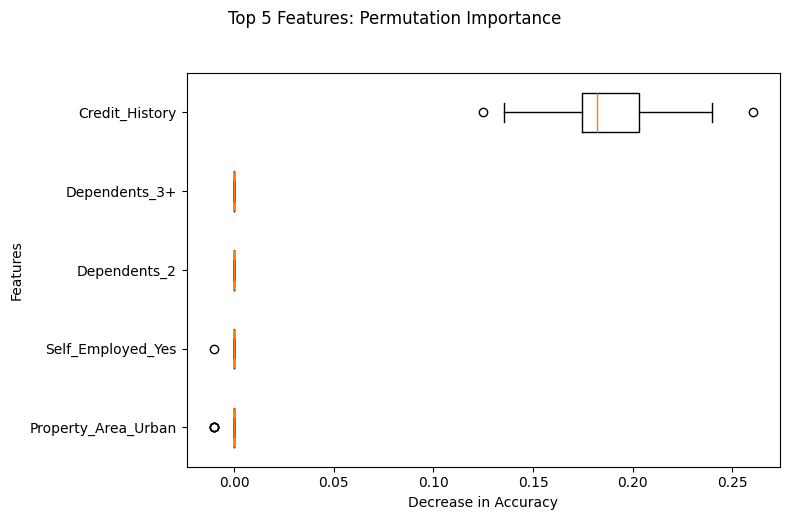

In [31]:
# 3. top5 feature boxplot
fig, ax1 = plt.subplots(
    1,
    1,
    figsize=(8, 5)
)

ax1.boxplot(
    result.importances[top5_idx].T,
    vert=False,
    labels=top5_features
)

fig.suptitle(
    "Top 5 Features: Permutation Importance",
    y=1.03
)

ax1.set_xlabel(
    "Decrease in Accuracy"
)

ax1.set_ylabel(
    "Features"
)

fig.tight_layout()

plt.show()


# 8. Partial dependence 

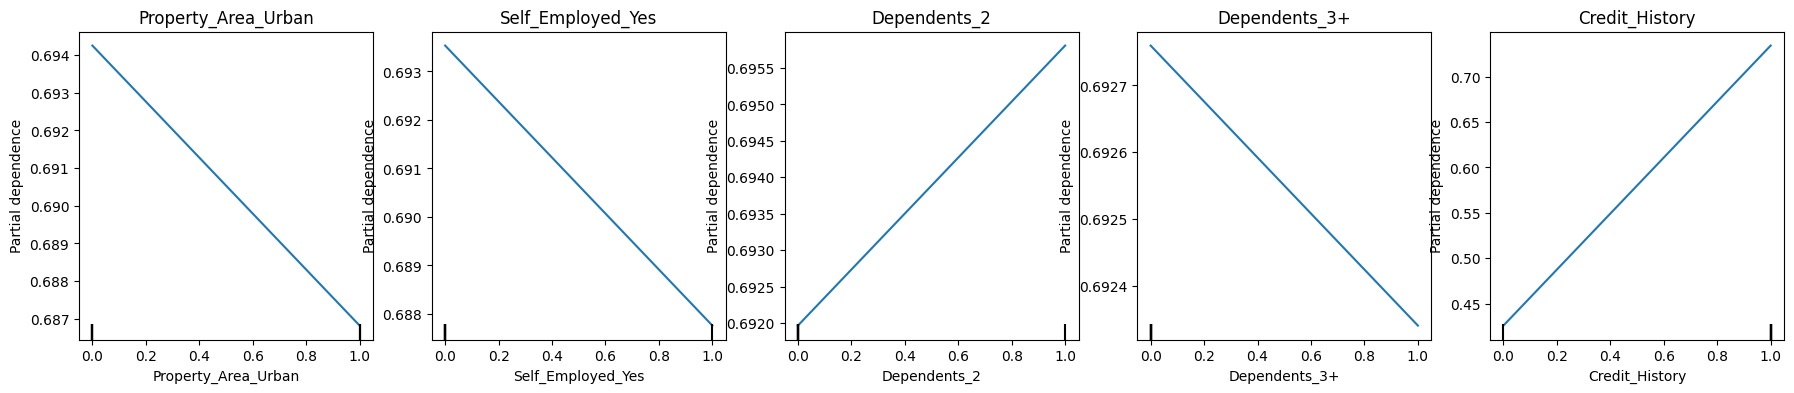

In [32]:
# 1. create PDP
fig, axes = plt.subplots(
    1,
    5,
    figsize=(22, 4)
)

for i, feature in enumerate(top5_features):

    PartialDependenceDisplay.from_estimator(
        clf,
        X_train,
        features=[feature],
        grid_resolution=20,
        ax=axes[i]
    )

    axes[i].set_title(feature)

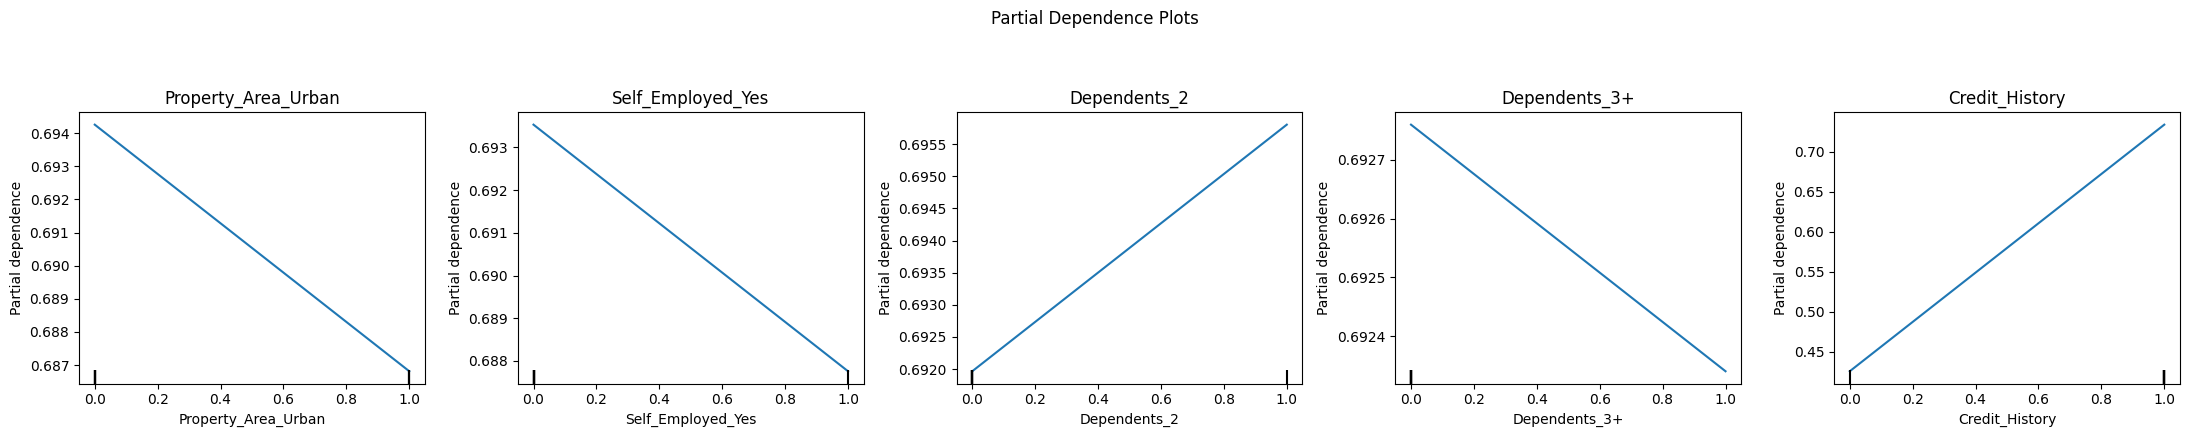

In [37]:
# Create PDPs

fig, axes = plt.subplots(
    1,
    5,
    figsize=(22, 4)
)

for i, feature in enumerate(top5_features):

    PartialDependenceDisplay.from_estimator(
        clf,
        X_train,
        features=[feature],
        grid_resolution=20,
        ax=axes[i]
    )

    axes[i].set_title(feature)

# collect y-axis ranges

ymins = [
    ax.get_ylim()[0]
    for ax in axes
]

ymaxs = [
    ax.get_ylim()[1]
    for ax in axes
]

# common limits

common_ylim = (
    min(ymins),
    max(ymaxs)
)

# apply same limits

for ax in axes:
    ax.set_ylim(common_ylim)

plt.suptitle(
    "Partial Dependence Plots",
    y=1.08
)

plt.tight_layout()

plt.show()

## Interpretation

- The permutation importance plot shows that `Credit_History` is the most important feature for the Random Forest model. The X-axis represents the decrease in accuracy after each feature is randomly shuffled 20 times. Since `Credit_History` has the largest decrease, the model depends on this feature the most when predicting `Loan_Status`.

- In the partial dependence plots, the X-axis represents the value of each selected feature, and the Y-axis represents the model’s average predicted response for loan approval. A higher Y value means the model is predicting a higher likelihood of loan approval.

- `Credit_History` has the clearest pattern in the PDP. When credit history changes from 0 to 1, the predicted likelihood of loan approval increases strongly. This makes sense because applicants with a positive credit history are usually more likely to be approved.

- The other top features, such as `Property_Area_Urban`, `Self_Employed_Yes`, `Dependents_2`, and `Dependents_3+`, appear in the Top 5, but their effects are much smaller than `Credit_History`. Their PDPs are relatively flatter, which means changing these variables does not shift the model prediction as strongly.

- One thing that surprised me is that income-related variables such as `ApplicantIncome`, `CoapplicantIncome`, and `LoanAmount` were not in the Top 5. I expected those financial variables to be more important, but the model seems to rely more on credit history and categorical applicant characteristics. One possible limitation is that correlated predictors may affect permutation importance because similar information can be shared across multiple variables.